In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("../data/diabetes.csv")

In [36]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [38]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [39]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
#Univariate analysis of target column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

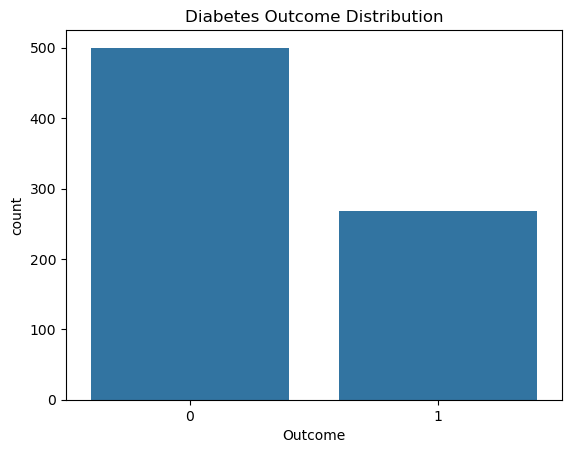

In [41]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

In [42]:
#total zero values
(df==0).sum()

#many zeroes in glucose, bp, skin thickness, insulin, bmi which is not medically possible
#treat them as missing values later

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

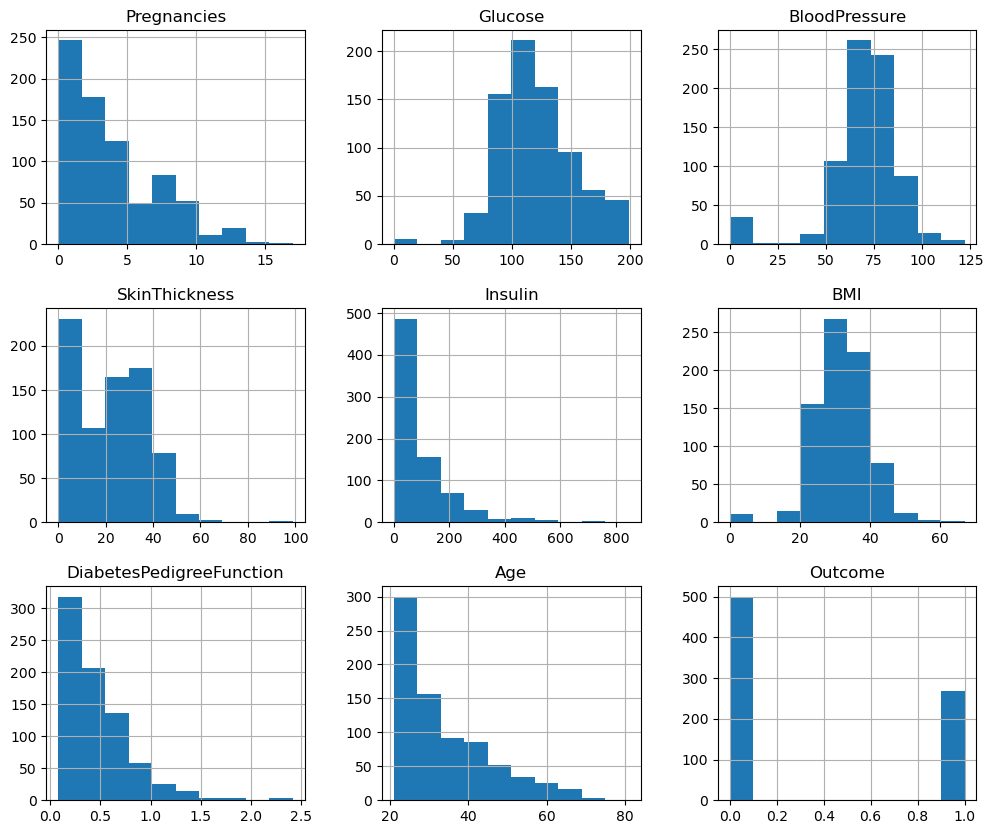

In [43]:
df.hist(figsize=(12,10))
plt.show()

#glucose, bp, bmi are normal
#pregnancies, isulin, skin thickness, diabetespedigreefunction, age are right skewed

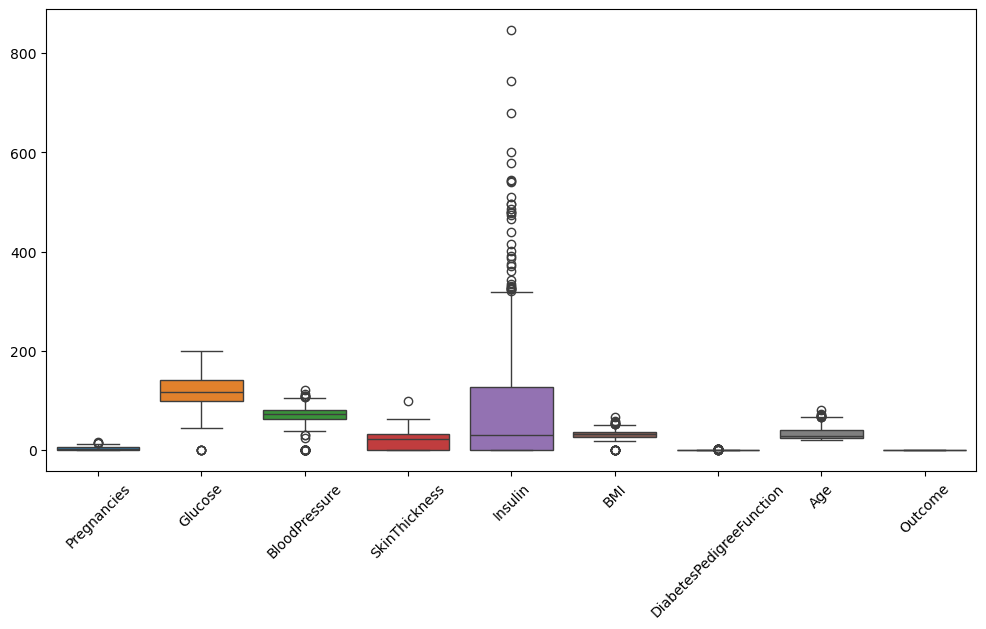

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

#insulin has extreme outliers
#bmi
#skin thickness has san extreme outlier
#bp also has few outliers

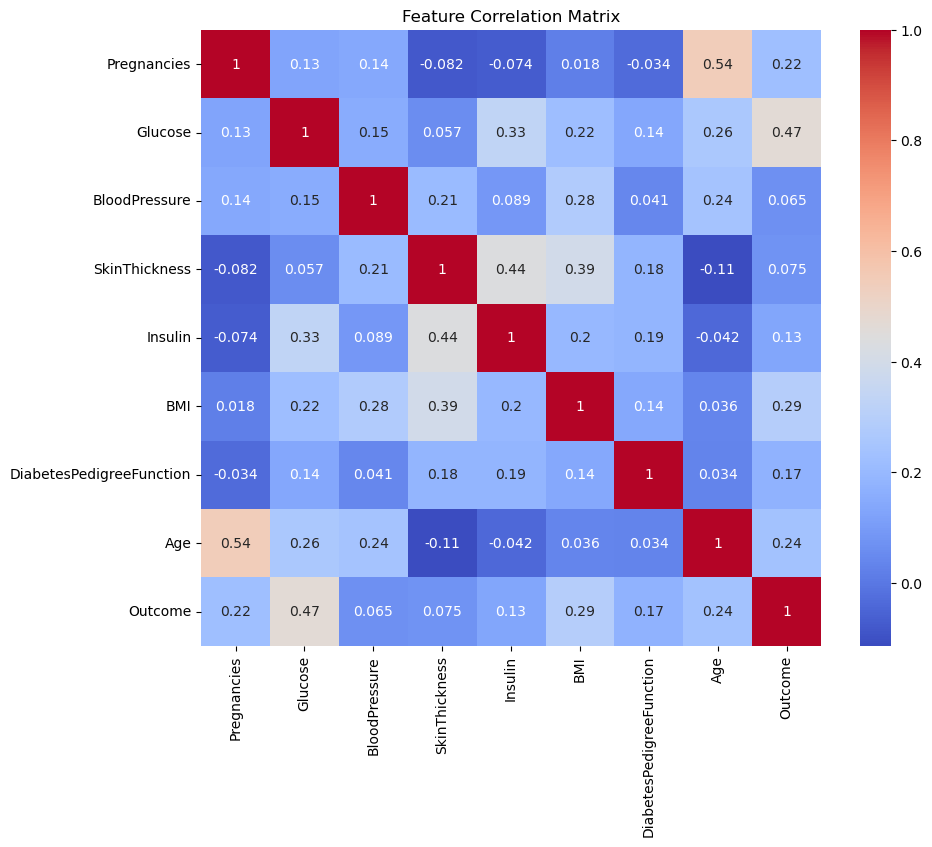

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

#highest correlation --> glucose  
#bmi and age are also informative

# PREPROCESSING

In [33]:
# turning all zeroes into NaN values
cols = ["Glucose","BloodPressure","SkinThickness","Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

In [30]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
151,4,114.0,65.0,29.0,125.0,21.9,0.432,37,0
579,2,197.0,70.0,99.0,125.0,34.7,0.575,62,1
24,11,143.0,94.0,33.0,146.0,36.6,0.254,51,1
607,1,92.0,62.0,25.0,41.0,19.5,0.482,25,0
479,4,132.0,86.0,31.0,125.0,28.0,0.419,63,0


In [53]:
# train and test split
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [54]:
from sklearn.impute import SimpleImputer

mean_cols = ["Glucose", "BloodPressure", "BMI"]
median_cols = ["SkinThickness", "Insulin"]

mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")

X_train[mean_cols] = mean_imputer.fit_transform(X_train[mean_cols])
X_test[mean_cols] = mean_imputer.transform(X_test[mean_cols])

X_train[median_cols] = median_imputer.fit_transform(X_train[median_cols])
X_test[median_cols] = median_imputer.transform(X_test[median_cols])


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
